<a href="https://colab.research.google.com/github/amarnoorkaur/EmoSense/blob/main/EmoSense.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns

In [2]:
import kagglehub
path = kagglehub.dataset_download("sahideseker/tweet-sentiment-classification-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tweet-sentiment-classification-dataset' dataset.
Path to dataset files: /kaggle/input/tweet-sentiment-classification-dataset


In [3]:
print("Files in the directory:")
for file in os.listdir(path):
    print(f" - {file}")
file_path = os.path.join(path, "tweet_sentiment.csv")


Files in the directory:
 - tweet_sentiment.csv


In [4]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(file_path)

In [14]:
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
print("\nFirst 5 rows of the dataset:")
print(df.head(900)) #since there are no emojis here, no need to convert emojis to text for comments, will use some new dataset for the same


First 5 rows of the dataset:
                                   tweet sentiment
0              The event starts at 5 PM.   neutral
1            I hate how this turned out.  negative
2                  Fantastic experience!  positive
3                  Fantastic experience!  positive
4          This is the worst thing ever!  negative
5              The event starts at 5 PM.   neutral
6                  What a wonderful day!  positive
7                 Great job by the team!  positive
8                  What a wonderful day!  positive
9                It ruined my whole day.  negative
10    Just finished reading the article.   neutral
11                     Today is Tuesday.   neutral
12         This is the worst thing ever!  negative
13           I hate how this turned out.  negative
14                     Today is Tuesday.   neutral
15                 What a wonderful day!  positive
16   Really disappointed in the results.  negative
17          I'm so happy about the news!  positive
1

In [15]:
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")


Dataset shape: (1000, 2)

Column names: ['tweet', 'sentiment']

Data types:
tweet        object
sentiment    object
dtype: object


In [16]:
import re


def clean_tweet(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags (keep the word)
    text = re.sub(r'#', '', text)

    # Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text



In [17]:
df['clean_tweet'] = df['tweet'].apply(clean_tweet) #converted emojis to better text to clean the same


In [18]:
print(df.columns)


Index(['tweet', 'sentiment', 'clean_tweet'], dtype='object')


In [19]:
from sklearn.model_selection import train_test_split
X = df['clean_tweet']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1,2), min_df=2)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

print("X_train_vec shape:", X_train_vec.shape)   # (n_train_samples, n_features)
print("X_test_vec shape: ", X_test_vec.shape)    # (n_test_samples, n_features)


X_train_vec shape: (800, 115)
X_test_vec shape:  (200, 115)


In [26]:
# get vocabulary mapping (term -> column index)
vocab = vectorizer.vocabulary_
# top 20 terms by index order (not by score)
sorted_terms = sorted(vocab.items(), key=lambda x: x[1])[:20]
print(sorted_terms)

# OR show highest-idf terms (rare but discriminative)
idf_scores = dict(zip(vectorizer.get_feature_names_out(), vectorizer.idf_))
top_idf = sorted(idf_scores.items(), key=lambda x: x[1], reverse=True)[:20]
top_idf


[('about', np.int64(0)), ('about the', np.int64(1)), ('absolutely', np.int64(2)), ('absolutely loved', np.int64(3)), ('again', np.int64(4)), ('article', np.int64(5)), ('at', np.int64(6)), ('at pm', np.int64(7)), ('by', np.int64(8)), ('by the', np.int64(9)), ('cloudy', np.int64(10)), ('cloudy outside', np.int64(11)), ('day', np.int64(12)), ('decision', np.int64(13)), ('disappointed', np.int64(14)), ('disappointed in', np.int64(15)), ('event', np.int64(16)), ('event starts', np.int64(17)), ('ever', np.int64(18)), ('experience', np.int64(19))]


[('it', np.float64(4.466985122200159)),
 ('it ruined', np.float64(4.466985122200159)),
 ('my whole', np.float64(4.466985122200159)),
 ('ruined', np.float64(4.466985122200159)),
 ('ruined my', np.float64(4.466985122200159)),
 ('whole', np.float64(4.466985122200159)),
 ('whole day', np.float64(4.466985122200159)),
 ('ever', np.float64(4.102342008612249)),
 ('is the', np.float64(4.102342008612249)),
 ('the worst', np.float64(4.102342008612249)),
 ('thing', np.float64(4.102342008612249)),
 ('thing ever', np.float64(4.102342008612249)),
 ('this is', np.float64(4.102342008612249)),
 ('worst', np.float64(4.102342008612249)),
 ('worst thing', np.float64(4.102342008612249)),
 ('disappointed', np.float64(3.996981492954423)),
 ('disappointed in', np.float64(3.996981492954423)),
 ('in', np.float64(3.996981492954423)),
 ('in the', np.float64(3.996981492954423)),
 ('really', np.float64(3.996981492954423))]

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500, solver='lbfgs', multi_class='auto')
model.fit(X_train_vec, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=500, multi_class='auto')

Accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

    negative       1.00      1.00      1.00        58
     neutral       1.00      1.00      1.00        63
    positive       1.00      1.00      1.00        79

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



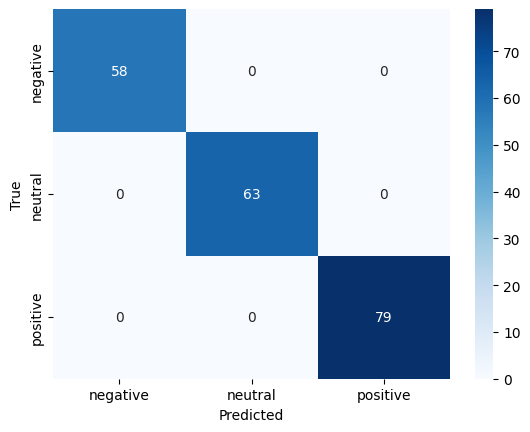

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [29]:
set(X_train).intersection(set(X_test))


{'absolutely loved this',
 'fantastic experience',
 'great job by the team',
 'i hate how this turned out',
 'im sick of this happening',
 'im so happy about the news',
 'it ruined my whole day',
 'its cloudy outside',
 'just finished reading the article',
 'really disappointed in the results',
 'such a terrible decision',
 'the event starts at pm',
 'this is the worst thing ever',
 'this update made my day',
 'today is tuesday',
 'what a wonderful day',
 'working from home again'}